In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv


# Setting a styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Connecting a database
load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connecting to PostgreSQL is success!")

Connecting to PostgreSQL is success!


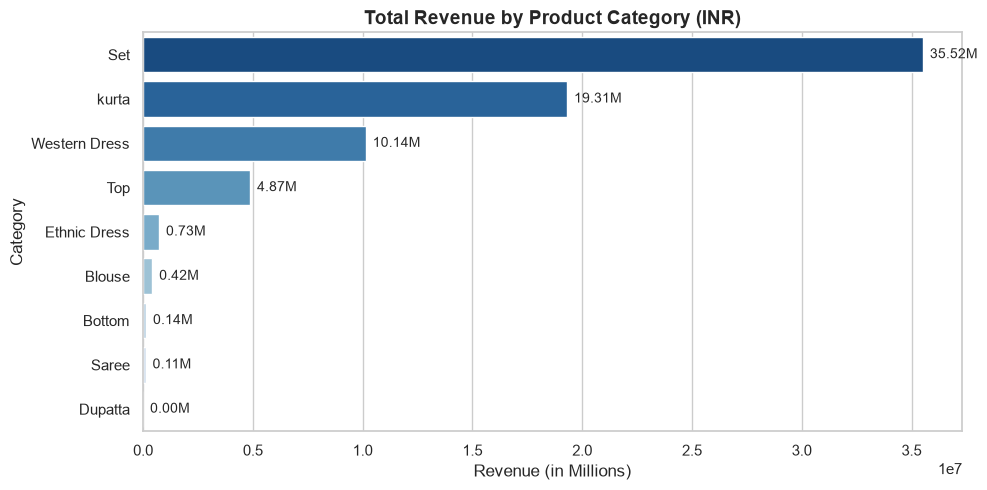

In [2]:
query_categories = """
SELECT 
    category,
    ROUND(SUM(amount)::numeric, 2) AS revenue
FROM amazon_sales
WHERE status NOT IN ('Cancelled', 'Pending') AND amount IS NOT NULL
GROUP BY category
ORDER BY revenue DESC;
"""
df_cat = pd.read_sql(query_categories, engine)

plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=df_cat, 
    x='revenue', 
    y='category', 
    hue='category', 
    palette='Blues_r', 
    legend=False
)

plt.title('Total Revenue by Product Category (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (in Millions)', fontsize=12)
plt.ylabel('Category', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width/1e6:.2f}M',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')
plt.tight_layout()
plt.show()

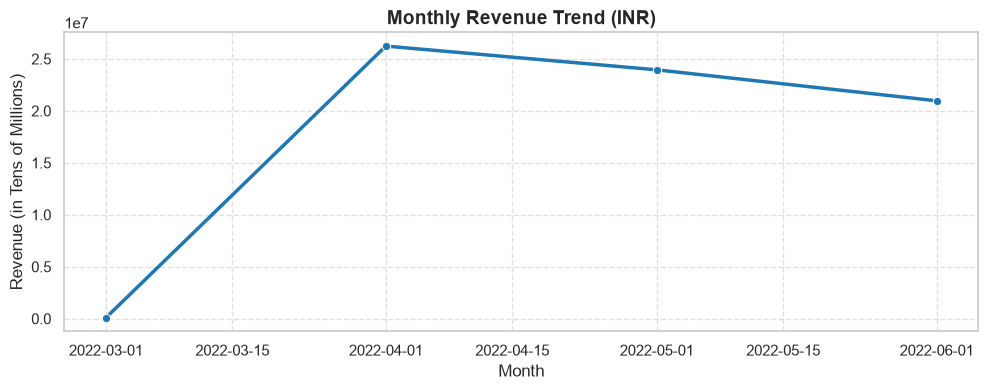

In [3]:
query_monthly = """
SELECT 
    DATE_TRUNC('month', date)::date AS sales_month,
    ROUND(SUM(amount)::numeric, 2) AS monthly_revenue
FROM amazon_sales
WHERE status NOT IN ('Cancelled', 'Pending') AND date IS NOT NULL
GROUP BY sales_month
ORDER BY sales_month;
"""

df_monthly = pd.read_sql(query_monthly, engine)

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_monthly, x='sales_month', y='monthly_revenue', marker='o', linewidth=2.5, color='#1f77b4')

plt.title('Monthly Revenue Trend (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (in Tens of Millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

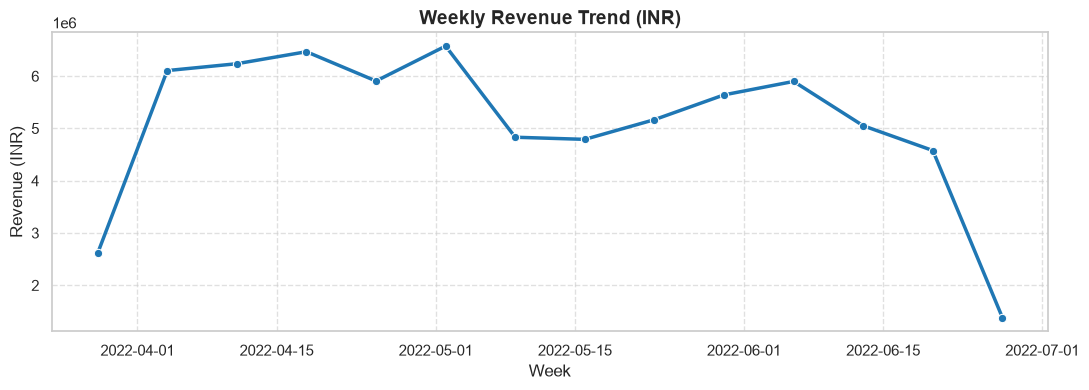

In [4]:
#Spliting to  the week revenue to make graph more correct
query_weekly = """
SELECT 
    DATE_TRUNC('week', date)::date AS sales_week,
    ROUND(SUM(amount)::numeric, 2) AS weekly_revenue
FROM amazon_sales
WHERE status NOT IN ('Cancelled', 'Pending') 
  AND date >= '2022-03-25'
GROUP BY sales_week
ORDER BY sales_week;
"""

df_weekly = pd.read_sql(query_weekly, engine)

plt.figure(figsize=(11, 4))
sns.lineplot(data=df_weekly, x='sales_week', y='weekly_revenue', marker='o', linewidth=2.5, color='#1f77b4')

plt.title('Weekly Revenue Trend (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Week', fontsize=12)
plt.ylabel('Revenue (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()